<a href="https://colab.research.google.com/github/aniii052/DMPM-lab-24cseaiml052/blob/main/exp_7_dmpm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cluster Labels:
[0 0 0 1 1 1]

Cluster Centers:
[[ 3.          3.33333333]
 [11.         11.33333333]]


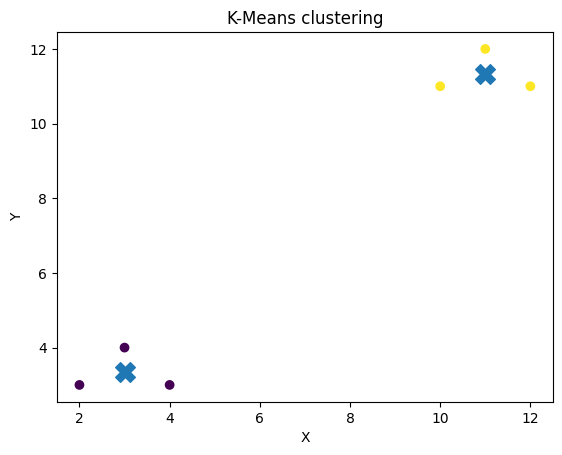

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
x=np.array([ [2,3],[3,4],[4,3],[10,11],[11,12],[12,11]])
kmeans=KMeans(n_clusters=2,random_state=42, n_init=10)
labels=kmeans.fit_predict(x)
print("Cluster Labels:")
print(labels)
print("\nCluster Centers:")
print(kmeans.cluster_centers_)
plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='X',s=200)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means clustering")
plt.show()

Cluster Labels:
[0 0 0 1 1 1]

Medoid Points:
[3 4]
[11 12]


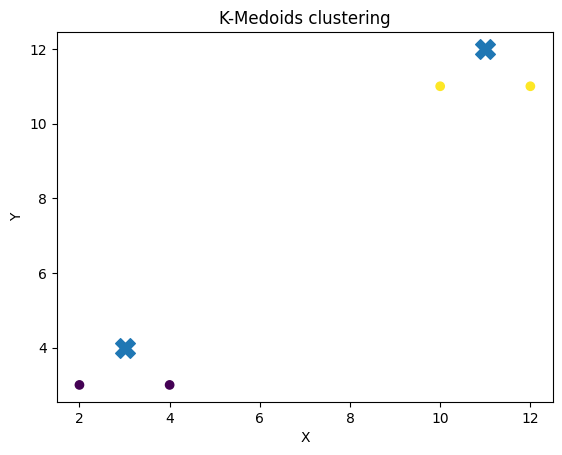

In [5]:
import numpy as np
import matplotlib.pyplot as plt
x=np.array([ [2,3],[3,4],[4,3],[10,11],[11,12],[12,11]])
k=2
medoid_indices=[0,3]
while True:
  distances=np.zeros((len(x),k))
  for i in range(len(x)):
    for j in range(k):
      distances[i,j]=np.linalg.norm(x[i]-x[medoid_indices[j]])
  labels=np.argmin(distances,axis=1)
  new_medoid_indices=[]
  for cluster in range(k):
    cluster_indices=np.where(labels==cluster)[0]
    if len(cluster_indices)==0:
      new_medoid_indices.append(medoid_indices[cluster])
      continue
    total_distances=[]
    for i in cluster_indices:
      total=0
      for j in cluster_indices:
        total+=np.linalg.norm(x[i]-x[j])
      total_distances.append(total)
    new_medoid=cluster_indices[np.argmin(total_distances)]
    new_medoid_indices.append(new_medoid)
  if new_medoid_indices== medoid_indices:
    break
  medoid_indices=new_medoid_indices
print("Cluster Labels:")
print(labels)
print("\nMedoid Points:")
for index in medoid_indices:
  print(x[index])
plt.scatter(x[:,0],x[:,1],c=labels)
medoids=x[medoid_indices]
plt.scatter(medoids[:,0],medoids[:,1],marker='X',s=200)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Medoids clustering")
plt.show()